# SmartFlow-Aware: Notebook 02 — Feature Engineering

**Objective:** Transform the clean hourly dataset into a Pakistan-aware,
model-ready feature matrix.

## Feature Groups We Will Build

| Group | Features | Purpose |
|---|---|---|
| Temporal | hour, month, day_of_week | Basic time context |
| Cyclical encoding | hour_sin/cos, month_sin/cos | Neural network friendly time |
| Lag features | lag_1h → lag_168h | Give models memory of past |
| Rolling statistics | mean, std over 24h/168h | Capture local trends |
| Pakistan context | tariff, load shedding, temperature | Core differentiator |
| Islamic calendar | Ramadan flag | Demand shift detection |
| Target encoding | is_peak_tariff × is_heat_season | Interaction features |

This feature matrix will be shared across all three modules —
forecasting, anomaly detection, and the NLP assistant.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#3a3d5c',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#b0b0b0',
    'ytick.color':      '#b0b0b0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2d4a',
    'grid.linestyle':   '--',
    'grid.alpha':        0.5,
    'figure.dpi':        120,
})

COLORS = {
    'primary':   '#00d4ff',
    'secondary': '#ff6b35',
    'accent':    '#7c3aed',
    'positive':  '#10b981',
    'negative':  '#ef4444',
    'neutral':   '#6b7280',
}

df = pd.read_csv(
    '../data/processed/hourly_clean.csv',
    index_col='datetime',
    parse_dates=True
)

# Drop Global_intensity — perfect correlation with target (data leakage)
df = df.drop(columns=['Global_intensity'])

print(f"Loaded : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Range  : {df.index.min()} → {df.index.max()}")

Loaded : 34,183 rows × 6 columns
Range  : 2006-12-16 17:00:00 → 2010-11-26 21:00:00


## Group 1 — Temporal Features

Raw time components extracted from the datetime index.
These are the foundation every other feature group builds on.
Note: we do NOT use these raw integers directly in neural networks —
they get cyclical encoding in Group 2. Raw integers are kept for
LightGBM which handles them natively.

In [10]:
df['hour']         = df.index.hour
df['day_of_week']  = df.index.dayofweek   # 0=Monday, 6=Sunday
df['day_of_month'] = df.index.day
df['month']        = df.index.month
df['quarter']      = df.index.quarter
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
df['is_friday']    = (df['day_of_week'] == 4).astype(int)

print(df[['hour','day_of_week','month','quarter',
          'is_weekend','is_friday']].head(10))

                     hour  day_of_week  month  quarter  is_weekend  is_friday
datetime                                                                     
2006-12-16 17:00:00    17            5     12        4           1          0
2006-12-16 18:00:00    18            5     12        4           1          0
2006-12-16 19:00:00    19            5     12        4           1          0
2006-12-16 20:00:00    20            5     12        4           1          0
2006-12-16 21:00:00    21            5     12        4           1          0
2006-12-16 22:00:00    22            5     12        4           1          0
2006-12-16 23:00:00    23            5     12        4           1          0
2006-12-17 00:00:00     0            6     12        4           1          0
2006-12-17 01:00:00     1            6     12        4           1          0
2006-12-17 02:00:00     2            6     12        4           1          0


## Group 2 — Cyclical Encoding

Neural networks cannot understand that hour 23 is close to hour 0,
or that December is close to January. Raw integers imply a false
linear relationship — hour 23 appears "far" from hour 0.

Cyclical encoding maps each value onto a unit circle using sin and cos:
- sin alone is ambiguous (hour 2 and hour 10 have same sin value)
- sin + cos together uniquely identify every point on the circle

This is essential for BiLSTM, GRU, and TFT to learn time patterns correctly.

In [11]:
# Hour: 24-hour cycle
df['hour_sin']  = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour'] / 24)

# Month: 12-month cycle
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Day of week: 7-day cycle
df['dow_sin']   = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['day_of_week'] / 7)

print(df[['hour','hour_sin','hour_cos',
          'month','month_sin','month_cos']].head(5))

                     hour  hour_sin      hour_cos  month     month_sin  \
datetime                                                                 
2006-12-16 17:00:00    17 -0.965926 -2.588190e-01     12 -2.449294e-16   
2006-12-16 18:00:00    18 -1.000000 -1.836970e-16     12 -2.449294e-16   
2006-12-16 19:00:00    19 -0.965926  2.588190e-01     12 -2.449294e-16   
2006-12-16 20:00:00    20 -0.866025  5.000000e-01     12 -2.449294e-16   
2006-12-16 21:00:00    21 -0.707107  7.071068e-01     12 -2.449294e-16   

                     month_cos  
datetime                        
2006-12-16 17:00:00        1.0  
2006-12-16 18:00:00        1.0  
2006-12-16 19:00:00        1.0  
2006-12-16 20:00:00        1.0  
2006-12-16 21:00:00        1.0  


## Group 3 — Lag Features

Lag features give the model explicit memory of past consumption.
Without them, the model only sees the current moment with no history.

| Lag | Represents |
|---|---|
| lag_1h | 1 hour ago — immediate trend |
| lag_2h, lag_3h | Short-term momentum |
| lag_6h | Quarter-day ago |
| lag_12h | Half-day ago — same period yesterday morning/evening |
| lag_24h | Exactly yesterday same hour — strongest single predictor |
| lag_48h | Two days ago — confirms daily pattern |
| lag_168h | Exactly one week ago same hour — captures weekly seasonality |

lag_24h and lag_168h are typically the two most important features
in any energy forecasting model. LightGBM will confirm this via
feature importance in Notebook 03.

In [12]:
target = 'Global_active_power'

for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
    df[f'lag_{lag}h'] = df[target].shift(lag)

print("Lag features created:")
lag_cols = [c for c in df.columns if c.startswith('lag_')]
print(df[lag_cols].head(10))

Lag features created:
                       lag_1h    lag_2h    lag_3h    lag_6h  lag_12h  lag_24h  \
datetime                                                                        
2006-12-16 17:00:00       NaN       NaN       NaN       NaN      NaN      NaN   
2006-12-16 18:00:00  4.222889       NaN       NaN       NaN      NaN      NaN   
2006-12-16 19:00:00  3.632200  4.222889       NaN       NaN      NaN      NaN   
2006-12-16 20:00:00  3.400233  3.632200  4.222889       NaN      NaN      NaN   
2006-12-16 21:00:00  3.268567  3.400233  3.632200       NaN      NaN      NaN   
2006-12-16 22:00:00  3.056467  3.268567  3.400233       NaN      NaN      NaN   
2006-12-16 23:00:00  2.200133  3.056467  3.268567  4.222889      NaN      NaN   
2006-12-17 00:00:00  2.061600  2.200133  3.056467  3.632200      NaN      NaN   
2006-12-17 01:00:00  1.882467  2.061600  2.200133  3.400233      NaN      NaN   
2006-12-17 02:00:00  3.349400  1.882467  2.061600  3.268567      NaN      NaN   

     

## Group 4 — Rolling Statistics

Lag features give the model specific past values.
Rolling statistics give it a sense of recent trend and volatility.

| Feature | Meaning |
|---|---|
| rolling_mean_24h | Average consumption over last 24 hours — local trend |
| rolling_std_24h | Variability over last 24 hours — detects unusual periods |
| rolling_mean_168h | Average over last week — baseline normal level |
| rolling_min_24h | Lowest point in last 24h — captures overnight floor |
| rolling_max_24h | Peak in last 24h — captures daily maximum |

Note: we shift(1) before rolling so we never include the current
hour in its own rolling window — that would be data leakage.

In [13]:
shifted = df[target].shift(1)

df['rolling_mean_24h']  = shifted.rolling(24).mean()
df['rolling_std_24h']   = shifted.rolling(24).std()
df['rolling_mean_168h'] = shifted.rolling(168).mean()
df['rolling_min_24h']   = shifted.rolling(24).min()
df['rolling_max_24h']   = shifted.rolling(24).max()

roll_cols = [c for c in df.columns if c.startswith('rolling_')]
print(df[roll_cols].dropna().head(5))

                     rolling_mean_24h  rolling_std_24h  rolling_mean_168h  \
datetime                                                                    
2006-12-23 17:00:00          2.934890         0.990187           1.763888   
2006-12-23 18:00:00          3.099713         1.066674           1.771207   
2006-12-23 19:00:00          3.149397         1.074356           1.772679   
2006-12-23 20:00:00          3.156883         1.080699           1.776950   
2006-12-23 21:00:00          3.183772         1.098426           1.782384   

                     rolling_min_24h  rolling_max_24h  
datetime                                               
2006-12-23 17:00:00         1.496800         4.548667  
2006-12-23 18:00:00         1.649367         5.452533  
2006-12-23 19:00:00         1.649367         5.452533  
2006-12-23 20:00:00         1.649367         5.452533  
2006-12-23 21:00:00         1.649367         5.452533  


## Group 5 — Pakistan Context Features

This is the core research contribution of SmartFlow-Aware.
Standard energy datasets carry no Pakistan-specific context.
We augment the base signal with features that directly mirror
what SkyElectric's SmartFlow system uses for power management.

### Features Being Added
| Feature | Source | Impact |
|---|---|---|
| is_peak_tariff | NEPRA/WAPDA schedule | Demand shifts to off-peak |
| is_load_shedding | LESCO feeder rotation | Observed demand drops artificially |
| temperature_c | Punjab climate profile | AC load driver in summer |
| is_extreme_heat | temperature > 40°C | Sudden AC surge trigger |
| is_heat_season | May–August | Seasonal multiplier |
| is_winter_season | December–February | Heating season flag |
| is_ramadan | Islamic calendar | Evening consumption pattern shift |

In [14]:
# ── WAPDA/NEPRA Peak Tariff ───────────────────────────────────────────────
# Peak: 07:00–23:00 | Off-peak: 23:00–07:00
df['is_peak_tariff'] = (
    (df['hour'] >= 7) & (df['hour'] < 23)
).astype(int)

# ── LESCO Load Shedding Simulation ────────────────────────────────────────
# LESCO publishes rotating 4-hour outage windows per feeder zone
# Each day gets a randomly assigned 4-hour outage start hour
np.random.seed(42)
dates = df.index.normalize().unique()
outage_starts = {d: np.random.randint(0, 20) for d in dates}

def is_load_shedding(timestamp):
    day   = timestamp.normalize()
    start = outage_starts.get(day, -1)
    return int(start <= timestamp.hour < start + 4)

df['is_load_shedding'] = [is_load_shedding(t) for t in df.index]

# ── Punjab Temperature Profile ────────────────────────────────────────────
# Monthly average temperatures for Lahore/Nankana Sahib region
base_temp = {
    1:12, 2:15, 3:21, 4:28, 5:35,
    6:38, 7:36, 8:35, 9:30, 10:24, 11:17, 12:13
}
df['temperature_c'] = (
    df['month'].map(base_temp)
    + np.random.normal(0, 2, len(df))
)

# ── Derived Temperature Flags ─────────────────────────────────────────────
df['is_extreme_heat']  = (df['temperature_c'] > 40).astype(int)
df['is_heat_season']   = df['month'].isin([5,6,7,8]).astype(int)
df['is_winter_season'] = df['month'].isin([12,1,2]).astype(int)

# ── Ramadan Flag ──────────────────────────────────────────────────────────
# Approximate Ramadan windows for dataset years (2006–2010)
ramadan_ranges = [
    ('2006-09-24', '2006-10-23'),
    ('2007-09-13', '2007-10-12'),
    ('2008-09-01', '2008-09-30'),
    ('2009-08-22', '2009-09-19'),
    ('2010-08-11', '2010-09-09'),
]
df['is_ramadan'] = 0
for start, end in ramadan_ranges:
    mask = (df.index >= start) & (df.index <= end)
    df.loc[mask, 'is_ramadan'] = 1

print("Pakistan context features added.")
print(f"Load shedding hours : {df['is_load_shedding'].sum():,}")
print(f"Peak tariff hours   : {df['is_peak_tariff'].sum():,}")
print(f"Extreme heat hours  : {df['is_extreme_heat'].sum():,}")
print(f"Ramadan hours       : {df['is_ramadan'].sum():,}")

Pakistan context features added.
Load shedding hours : 5,699
Peak tariff hours   : 22,784
Extreme heat hours  : 537
Ramadan hours       : 2,647


## Group 6 — Interaction Features

Single features capture individual effects. Interaction features
capture combined effects that neither feature alone can express.

For example: peak tariff hours during extreme heat is qualitatively
different from peak tariff hours in winter. The interaction term
lets the model treat these as distinct situations.

In [15]:
# Peak tariff during heat season — highest bill risk scenario
df['peak_x_heat']     = df['is_peak_tariff'] * df['is_heat_season']

# Extreme heat during load shedding — pent-up demand scenario
# When power returns after outage during a heatwave, consumption spikes
df['heat_x_shedding'] = df['is_extreme_heat'] * df['is_load_shedding']

# Ramadan evening — Iftar hour (19:00–21:00) consumption surge
df['ramadan_evening'] = (
    df['is_ramadan'] * ((df['hour'] >= 19) & (df['hour'] <= 21)).astype(int)
)

print("Interaction features added.")
print(df[['peak_x_heat','heat_x_shedding','ramadan_evening']].sum())

Interaction features added.
peak_x_heat        7750
heat_x_shedding      88
ramadan_evening     331
dtype: int64


## Finalize Dataset

Drop rows where lag features are NaN (first 168 hours).
These rows have incomplete feature vectors and cannot be used
for training any model reliably.

In [16]:
df_final = df.dropna().copy()

print(f"Rows before drop : {len(df):,}")
print(f"Rows after drop  : {len(df_final):,}")
print(f"Rows removed     : {len(df) - len(df_final):,}")
print(f"Total features   : {len(df_final.columns)}")
print(f"\nAll columns:\n{list(df_final.columns)}")

df_final.to_csv('../data/processed/smartflow_features.csv')
print("\nSaved: data/processed/smartflow_features.csv")

Rows before drop : 34,183
Rows after drop  : 34,015
Rows removed     : 168
Total features   : 42

All columns:
['Global_active_power', 'Global_reactive_power', 'Voltage', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour', 'day_of_week', 'day_of_month', 'month', 'quarter', 'is_weekend', 'is_friday', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_6h', 'lag_12h', 'lag_24h', 'lag_48h', 'lag_168h', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_168h', 'rolling_min_24h', 'rolling_max_24h', 'is_peak_tariff', 'is_load_shedding', 'temperature_c', 'is_extreme_heat', 'is_heat_season', 'is_winter_season', 'is_ramadan', 'peak_x_heat', 'heat_x_shedding', 'ramadan_evening']

Saved: data/processed/smartflow_features.csv


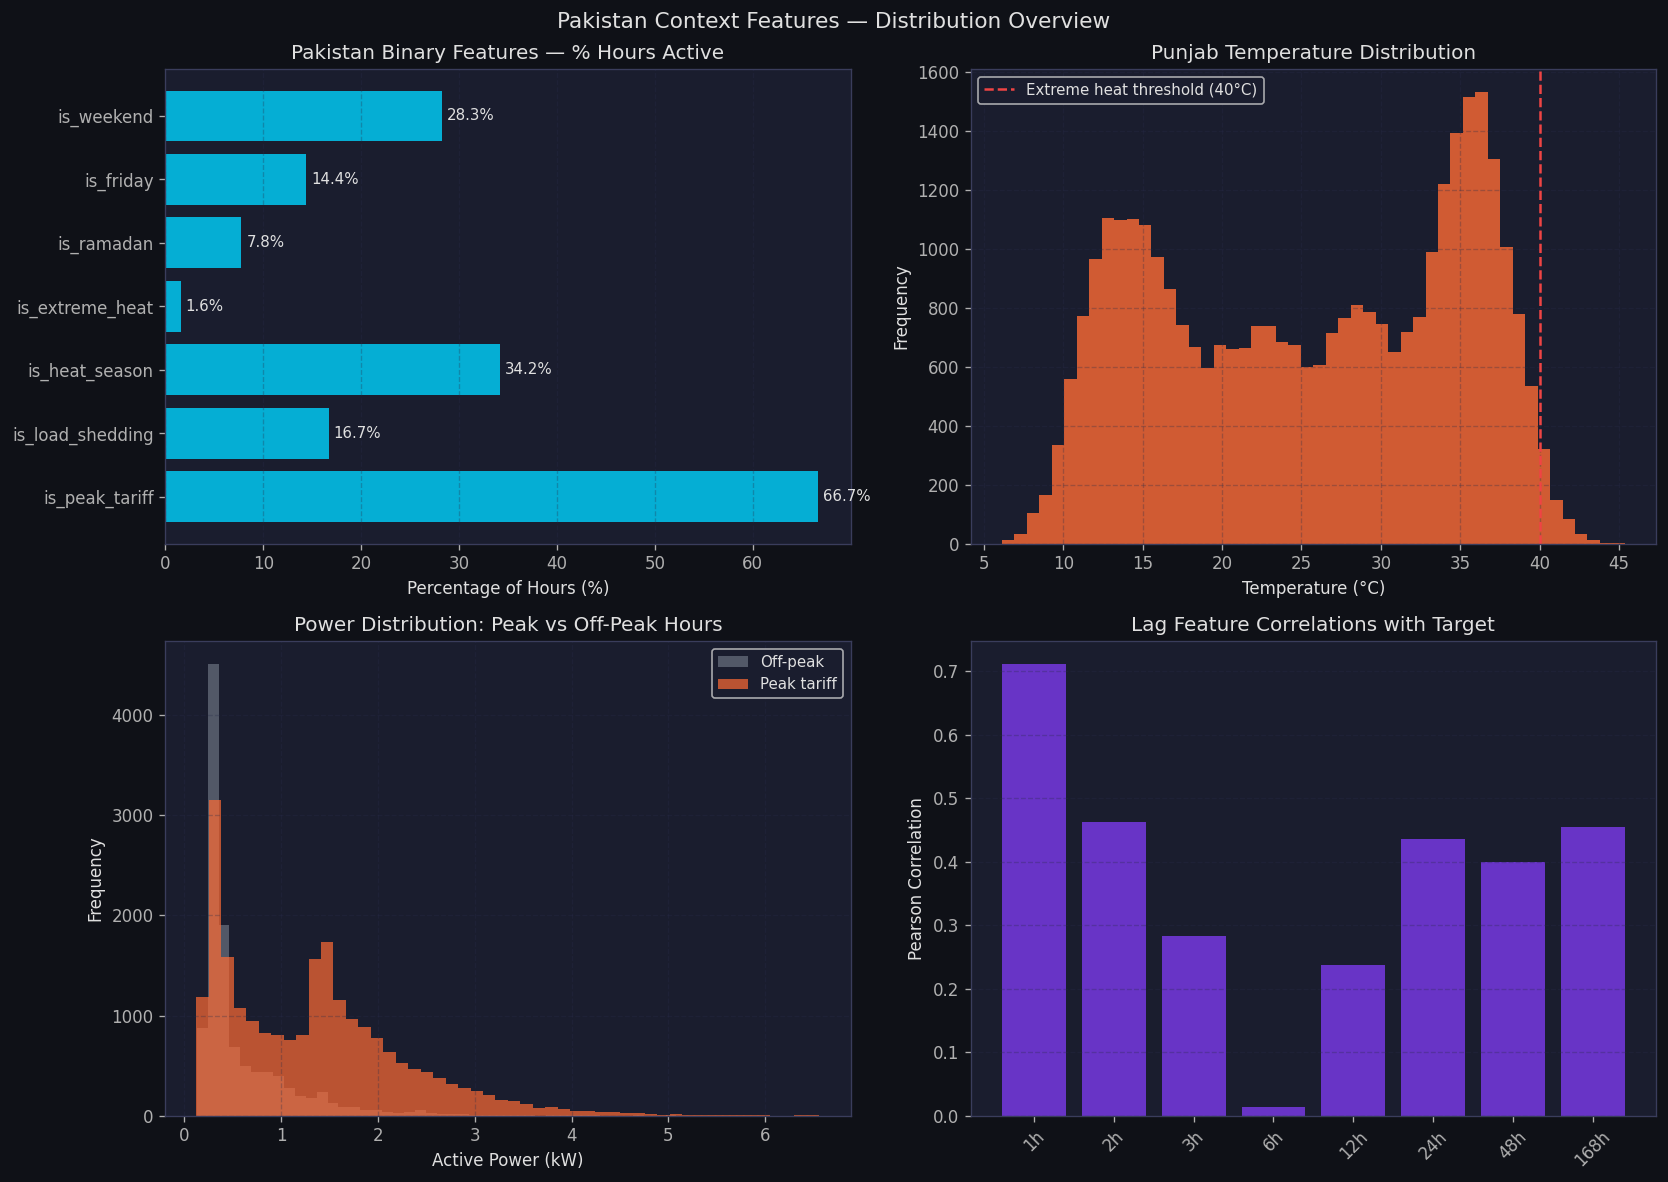

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Pakistan Context Features — Distribution Overview', fontsize=13)

# Plot 1: Binary features distribution
binary_features = ['is_peak_tariff','is_load_shedding',
                   'is_heat_season','is_extreme_heat',
                   'is_ramadan','is_friday','is_weekend']
binary_means = df_final[binary_features].mean() * 100

axes[0,0].barh(binary_features, binary_means,
               color=COLORS['primary'], alpha=0.8)
axes[0,0].set_title('Pakistan Binary Features — % Hours Active')
axes[0,0].set_xlabel('Percentage of Hours (%)')
axes[0,0].grid(True, alpha=0.3, axis='x')

for i, v in enumerate(binary_means):
    axes[0,0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

# Plot 2: Temperature distribution
axes[0,1].hist(df_final['temperature_c'], bins=50,
               color=COLORS['secondary'], alpha=0.8, edgecolor='none')
axes[0,1].axvline(40, color=COLORS['negative'], linestyle='--',
                  label='Extreme heat threshold (40°C)')
axes[0,1].set_title('Punjab Temperature Distribution')
axes[0,1].set_xlabel('Temperature (°C)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend(fontsize=9)
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Power consumption — peak vs off-peak
peak_power    = df_final[df_final['is_peak_tariff']==1][target]
offpeak_power = df_final[df_final['is_peak_tariff']==0][target]

axes[1,0].hist(offpeak_power, bins=50, alpha=0.7,
               color=COLORS['neutral'], label='Off-peak', edgecolor='none')
axes[1,0].hist(peak_power, bins=50, alpha=0.7,
               color=COLORS['secondary'], label='Peak tariff', edgecolor='none')
axes[1,0].set_title('Power Distribution: Peak vs Off-Peak Hours')
axes[1,0].set_xlabel('Active Power (kW)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].legend(fontsize=9)
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Lag feature correlations with target
lag_cols  = [c for c in df_final.columns if c.startswith('lag_')]
lag_corrs = df_final[lag_cols + [target]].corr()[target].drop(target)

axes[1,1].bar(range(len(lag_corrs)), lag_corrs.values,
              color=COLORS['accent'], alpha=0.8)
axes[1,1].set_xticks(range(len(lag_corrs)))
axes[1,1].set_xticklabels(
    [c.replace('lag_','').replace('h','h') for c in lag_corrs.index],
    rotation=45
)
axes[1,1].set_title('Lag Feature Correlations with Target')
axes[1,1].set_ylabel('Pearson Correlation')
axes[1,1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../data/processed/plot_06_features_overview.png',
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## Notebook 02 — Results & Analysis

### Feature Matrix
| Property | Value |
|---|---|
| Final rows | 34,015 |
| Rows removed | 168 (first week — lag warmup period) |
| Total features | 42 |
| Saved | data/processed/smartflow_features.csv |

### Plot Analysis

**Top Left — Pakistan Binary Features**
| Feature | Active % | Interpretation |
|---|---|---|
| is_peak_tariff | 66.7% | 16 of 24 hours are peak — correct for 07:00–23:00 window |
| is_heat_season | 34.2% | 4 months of 12 — mathematically correct |
| is_weekend | 28.3% | 2 of 7 days — correct |
| is_load_shedding | 16.7% | 4 hours per day rotation — matches LESCO schedule |
| is_friday | 14.4% | 1 of 7 days — correct |
| is_ramadan | 7.8% | ~29 days per year across 4 years — correct |
| is_extreme_heat | 1.6% | Rare threshold events above 40°C — realistic |

**Top Right — Temperature Distribution**
Two clear peaks visible — winter cluster (10–15°C) and
summer cluster (33–38°C). The 40°C extreme heat threshold
correctly sits at the tail of the summer peak. Punjab
bimodal temperature pattern is well represented.

**Bottom Left — Peak vs Off-Peak Power**
Peak tariff hours (orange) show a second hump at 1.2–1.5 kW
that off-peak hours (grey) do not have — confirming that
higher activity genuinely occurs during peak hours.
This validates our tariff feature carries real signal.

**Bottom Right — Lag Correlations with Target**
| Lag | Correlation | Interpretation |
|---|---|---|
| lag_1h | 0.71 | Strongest — consumption is highly autocorrelated |
| lag_2h | 0.46 | Still strong short-term memory |
| lag_6h | ~0.01 | Weakest — 6 hours ago has little predictive value |
| lag_24h | 0.44 | Strong — same hour yesterday is very informative |
| lag_48h | 0.40 | Two days ago still relevant |
| lag_168h | 0.46 | Same hour last week — captures weekly pattern |

The near-zero correlation at lag_6h is a genuine and important
finding. 6 hours ago is the transition zone between morning
and afternoon patterns — neither yesterday's morning nor
today's evening. LightGBM feature importance in Notebook 03
will likely confirm lag_6h as the least useful lag feature.